In [131]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
lag = 60
n_steps_out = 30
data = dataloader(path=path, supervised=True, lag=lag, n_steps_out=n_steps_out)

2024-04-18 09:11:06.705 | INFO     | utils.DataPreprocessing:load_csv:132 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-04-18 09:11:06.707 | INFO     | utils.DataPreprocessing:load_csv:134 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park


2024-04-18 09:11:06.897 | INFO     | utils.DataPreprocessing:feature_engineering:298 - shape: (8_523, 16)
┌───────────┬───────────────┬───────────┬──────┬───┬────────────┬────────────┬───────────┬─────────┐
│ AVG_TEMP  ┆ date          ┆ GSR       ┆ SUN  ┆ … ┆ dayofmonth ┆ weekofyear ┆ dayofyear ┆ quarter │
│ ---       ┆ ---           ┆ ---       ┆ ---  ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---     │
│ f32       ┆ datetime[μs]  ┆ f32       ┆ f32  ┆   ┆ i8         ┆ i8         ┆ i16       ┆ i8      │
╞═══════════╪═══════════════╪═══════════╪══════╪═══╪════════════╪════════════╪═══════════╪═════════╡
│ 29.200001 ┆ 1999-08-01    ┆ 25.1      ┆ 11.6 ┆ … ┆ 1          ┆ 30         ┆ 213       ┆ 3       │
│           ┆ 00:00:00      ┆           ┆      ┆   ┆            ┆            ┆           ┆         │
│ 29.1      ┆ 1999-08-02    ┆ 15.13     ┆ 7.0  ┆ … ┆ 2          ┆ 31         ┆ 214       ┆ 3       │
│           ┆ 00:00:00      ┆           ┆      ┆   ┆            ┆            ┆        

In [132]:
logger.success(data.X_train)
logger.success(data.y_train)
logger.success(data.X_test)
logger.success(data.y_test)

2024-04-18 09:11:06.977 | SUCCESS  | __main__:<module>:1 - shape: (6_746, 74)
┌───────┬─────┬──────┬─────┬───┬──────────────┬──────────────┬──────────────┬──────────────┐
│ GSR   ┆ SUN ┆ RH   ┆ UV  ┆ … ┆ AVG_TEMP_t-4 ┆ AVG_TEMP_t-3 ┆ AVG_TEMP_t-2 ┆ AVG_TEMP_t-1 │
│ ---   ┆ --- ┆ ---  ┆ --- ┆   ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│ f32   ┆ f32 ┆ f32  ┆ f32 ┆   ┆ f32          ┆ f32          ┆ f32          ┆ f32          │
╞═══════╪═════╪══════╪═════╪═══╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 20.25 ┆ 9.7 ┆ 75.0 ┆ 4.0 ┆ … ┆ 24.200001    ┆ 26.5         ┆ 26.200001    ┆ 27.299999    │
│ 14.15 ┆ 4.9 ┆ 75.0 ┆ 3.0 ┆ … ┆ 26.5         ┆ 26.200001    ┆ 27.299999    ┆ 26.799999    │
│ 20.18 ┆ 9.5 ┆ 75.0 ┆ 4.0 ┆ … ┆ 26.200001    ┆ 27.299999    ┆ 26.799999    ┆ 27.1         │
│ 14.42 ┆ 6.5 ┆ 77.0 ┆ 3.0 ┆ … ┆ 27.299999    ┆ 26.799999    ┆ 27.1         ┆ 27.799999    │
│ 9.28  ┆ 4.4 ┆ 72.0 ┆ 2.0 ┆ … ┆ 26.799999    ┆ 27.1         ┆ 27.799999    ┆ 27.0   

In [133]:
import polars as pl
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import lightgbm as lgb
 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
 
import warnings
warnings.filterwarnings('ignore')

In [134]:
data.y_train = data.y_train.to_numpy()
# data.y_val = data.y_val.to_numpy()
data.y_test = data.y_test.to_numpy()

In [135]:
lgb_train = lgb.Dataset(data.X_train, data.y_train)
lgb_eval = lgb.Dataset(data.X_test, data.y_test, reference=lgb_train)

In [136]:
# Define a dictionary of parameters for configuring the LightGBM regression model.
# params = {
#     'objective': 'regression',
#     'metric': 'rmse',
#     'boosting_type': 'gbdt',
#     'num_leaves': 31,
#     'learning_rate': 0.05,
#     'feature_fraction': 0.9,
# }

# params = {
#     "boosting_type": "gbdt",
#     "objective": "regression",
#     "metric": {"l2", "l1"},
#     "num_leaves": 31,
#     "learning_rate": 0.05,
#     "feature_fraction": 0.9,
#     "bagging_fraction": 0.8,
#     "bagging_freq": 5,
#     "verbose": 1,
# }

params = {
    'task': 'train',
    "boosting_type": "gbdt",
    "objective": "regression",
    # "metric": {"l2", "l1"},
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": 1,
    "num_iterations": 10000
}

In [137]:
# gbm = lgb.train(params,
#     lgb_train,
#     # num_boost_round=200,
#     valid_sets=[lgb_train, lgb_eval],
#     valid_names=['train','valid'],
#     callbacks= [lgb.early_stopping(10)]
#    )

In [138]:
##% Initial Models
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xg 

train_X = data.X_train
train_y = data.y_train

# RFReg = RandomForestRegressor(random_state = 0).fit(train_X, train_y)
# XGReg = xg.sklearn.XGBRegressor(
#     learning_rate=0.02,
#     n_estimators=900,
#     max_depth=4,
#     # early_stopping_rounds=50,
#     objective="reg:squarederror",
#     base_score=0.5,
#     min_child_weight=5,
#     booster="gbtree",
#     tree_method="hist",
#     device="cuda",
# ).fit(train_X, train_y)
# LGBMReg = lgb.LGBMRegressor(random_state=0).fit(train_X, train_y)

RFReg = RandomForestRegressor(random_state=0)
XGReg = xg.sklearn.XGBRegressor(
    learning_rate=0.02,
    n_estimators=900,
    max_depth=4,
    # early_stopping_rounds=50,
    objective="reg:squarederror",
    base_score=0.5,
    min_child_weight=5,
    booster="gbtree",
    tree_method="hist",
    device="cuda",
)
LGBMReg = lgb.LGBMRegressor(random_state=0)

In [139]:
##% evaluateRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluateRegressor(true, predicted, message = "Test set"):
    MSE = mean_squared_error(true, predicted,squared = True)
    MAE = mean_absolute_error(true, predicted)
    RMSE = mean_squared_error(true, predicted,squared = False)
    LogRMSE = mean_squared_error(np.log(true),np.log(predicted),squared = False)
    r2 = r2_score(true, predicted)
    print(message)
    print("R2:", r2)
    print("MSE:", MSE)
    print("MAE:", MAE)
    # print("RMSE:", RMSE)
    # print("LogRMSE:", LogRMSE)
    return r2, MSE, MAE

In [140]:
##% Plot True vs predicted values. Useful for continuous y 
def PlotPrediction(true,predicted, title = "Dataset: "):
    fig = plt.figure(figsize=(20,20))
    ax1 = fig.add_subplot(111)
    ax1.set_title(title + 'True vs Predicted')
    ax1.scatter(list(range(0,len(true))),true, s=10, c='r', marker="o", label='True')
    ax1.scatter(list(range(0,len(predicted))), predicted, s=10, c='b', marker="o", label='Predicted')
    plt.legend(loc='upper right')
    plt.show()

In [141]:
valid_X = data.X_test
valid_y = data.y_test

# ##% Model Metrics
# print("Random Forest Regressor") 
# predicted_train_y = RFReg.predict(train_X)
# evaluateRegressor(train_y,predicted_train_y,"    Training Set")
# predicted_valid_y = RFReg.predict(valid_X)
# evaluateRegressor(valid_y,predicted_valid_y,"    Test Set")
# print("\n")
    
# # print("Support Vector Machine") 
# # predicted_train_y = SVM.predict(train_X)
# # evaluateRegressor(train_y,predicted_train_y,"    Training Set")
# # predicted_valid_y = SVM.predict(valid_X)
# # evaluateRegressor(valid_y,predicted_valid_y,"    Test Set")
# # print("\n")

# print("XGBoost Regressor") 
# predicted_train_y = XGReg.predict(train_X)
# evaluateRegressor(train_y,predicted_train_y,"    Training Set")
# predicted_valid_y = XGReg.predict(valid_X)
# evaluateRegressor(valid_y,predicted_valid_y,"    Test Set")
# print("\n")

# print("LightGBM Regressor") 
# predicted_train_y = LGBMReg.predict(train_X)
# evaluateRegressor(train_y,predicted_train_y,"    Training Set")
# predicted_valid_y = LGBMReg.predict(valid_X)
# evaluateRegressor(valid_y,predicted_valid_y,"    Test Set")

In [142]:
from sklearn.ensemble import VotingRegressor
softvoting = VotingRegressor(estimators=[('xgb', XGReg),('lgb', LGBMReg),('rf', RFReg)])

# softvoting.fit(train_X, train_y)
# y_pred = softvoting.predict(valid_X)

from sklearn.multioutput import MultiOutputRegressor

# Create a multi-output regressor
multioutput_reg = MultiOutputRegressor(softvoting)

In [143]:
multioutput_reg.fit(
    X=train_X,
    y=train_y,
    # eval_set=[(data.X_test, data.y_test)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14897
[LightGBM] [Info] Number of data points in the train set: 6746, number of used features: 74
[LightGBM] [Info] Start training from score 23.088578
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002808 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14897
[LightGBM] [Info] Number of data points in the train set: 6746, number of used features: 74
[LightGBM] [Info] Start training from score 23.087674
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14897
[LightGBM] [Info] Number of data points in the train set: 6746, number of used features: 74
[LightGBM] [Info] Start t

MultiOutputRegressor(estimator=VotingRegressor(estimators=[('xgb',
                                                            XGBRegressor(base_score=0.5,
                                                                         booster='gbtree',
                                                                         callbacks=None,
                                                                         colsample_bylevel=None,
                                                                         colsample_bynode=None,
                                                                         colsample_bytree=None,
                                                                         device='cuda',
                                                                         early_stopping_rounds=None,
                                                                         enable_categorical=False,
                                                                         eval_metric=None,
                                                                         feature_types=None,
                                                                         gamma=None,
                                                                         grow_policy=None,
                                                                         importance_type=None,
                                                                         intera...
                                                                         learning_rate=0.02,
                                                                         max_bin=None,
                                                                         max_cat_threshold=None,
                                                                         max_cat_to_onehot=None,
                                                                         max_delta_step=None,
                                                                         max_depth=4,
                                                                         max_leaves=None,
                                                                         min_child_weight=5,
                                                                         missing=nan,
                                                                         monotone_constraints=None,
                                                                         multi_strategy=None,
                                                                         n_estimators=900,
                                                                         n_jobs=None,
                                                                         num_parallel_tree=None,
                                                                         random_state=None, ...)),
                                                           ('lgb',
                                                            LGBMRegressor(random_state=0)),
                                                           ('rf',
                                                            RandomForestRegressor(random_state=0))]))

In [144]:
y_pred = multioutput_reg.predict(data.X_test)

In [145]:
print("Voting Regressor") 
r2_score_test, mse_test, mae_test = evaluateRegressor(valid_y, y_pred, "Test Set")

Voting Regressor
Test Set
R2: 0.7906828280507335
MSE: 4.645313095968274
MAE: 1.6388473674303474


In [146]:
# data.date_test, data.y_test[:], y_pred[:]
print(data.date_test)
print(data.y_test[:])
print(y_pred[:])

shape: (1_687,)
Series: 'date' [datetime[μs]]
[
	2018-03-20 00:00:00
	2018-03-21 00:00:00
	2018-03-22 00:00:00
	2018-03-23 00:00:00
	2018-03-24 00:00:00
	…
	2022-10-27 00:00:00
	2022-10-28 00:00:00
	2022-10-29 00:00:00
	2022-10-30 00:00:00
	2022-10-31 00:00:00
]
[[20.7 18.  18.8 ... 17.8 19.4 21.9]
 [18.  18.8 19.7 ... 19.4 21.9 22.6]
 [18.8 19.7 20.5 ... 21.9 22.6 22.7]
 ...
 [25.2 24.7 25.  ... 21.8 22.2 22.4]
 [24.7 25.  21.5 ... 22.2 22.4 25.4]
 [25.  21.5 19.9 ... 22.4 25.4 25.1]]
[[21.12781399 20.72540262 19.96572818 ... 23.2471498  23.28517705
  23.57851914]
 [20.6400815  20.14387561 20.18035477 ... 23.61345912 23.58744668
  23.63073841]
 [18.84633242 19.36908029 19.67011068 ... 23.63806506 23.8148951
  23.17164533]
 ...
 [24.36997022 23.73270314 23.19575115 ... 20.39393906 20.43407394
  20.2956228 ]
 [24.13331231 22.74527783 22.39461605 ... 20.59088577 20.29982002
  19.69713147]
 [22.45422829 21.73591225 22.12859454 ... 20.62170267 19.77232398
  19.15939318]]


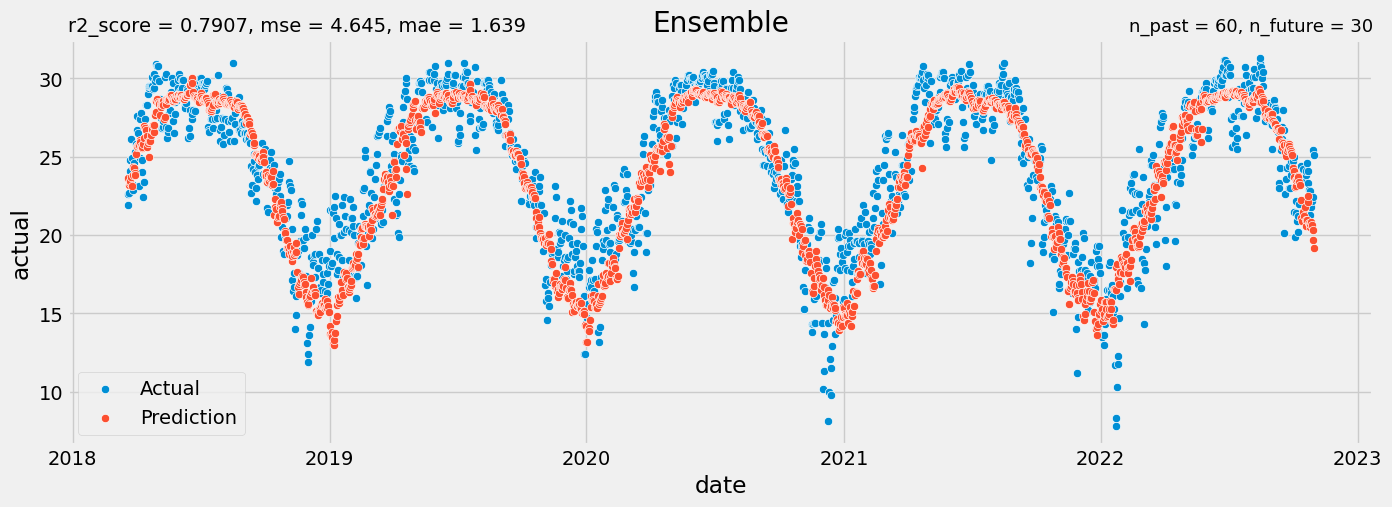

In [147]:
from polars import DataFrame
import seaborn as sns
import matplotlib.pyplot as plt


def plot_predictions(testing_dates, y_test, prediction):
    fig, ax = plt.subplots(
        figsize=(15, 5),
    )
    df_test = DataFrame(
        {"date": testing_dates, "actual": y_test, "prediction": prediction}
    )
    date_col = "date"
    data_col = df_test.columns[1]  # Assuming the first column is 'date'
    plot_data = df_test[[date_col, data_col]]
    sns.scatterplot(x=date_col, y=data_col, data=plot_data)

    data_col = df_test.columns[2]
    plot_data = df_test[[date_col, data_col]]
    sns.scatterplot(x=date_col, y=data_col, data=plot_data)
    plt.title("Ensemble")
    plt.title(f"n_past = {lag:}, n_future = {n_steps_out}", loc="right", fontsize=13)
    plt.title(
        f"r2_score = {r2_score_test:.4}, mse = {mse_test:.4}, mae = {mae_test:.4}",
        loc="left",
        fontsize=14,
    )
    plt.legend(["Actual", "Prediction"])
    plt.savefig(f"ensemble_{lag}_{n_steps_out}.png")

# plot_predictions(data.date_test, data.y_test[:, -1], y_pred[:])
plot_predictions(data.date_test, data.y_test[:, -1], y_pred[:, -1])
